In [1]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/Users/emmanuel/Documents/belugas/beluga-call-pipeline


In [2]:


import torch
import matplotlib.pyplot as plt
from datetime import timedelta

import numpy as np

import matplotlib.pyplot as plt

import time
from tqdm import tqdm
from datetime import datetime
import os
from data_preprocessing.spectrogram.spectrogram_generator import SPECT_GENERATOR, HYDROPHONE_SENSITIVITY
import pandas as pd
from models.quant_mobilenet import load_mobilenet_v3_quant_from_file
from data_preprocessing.spectrogram.spectrogram_generator import SpectrogramGenerator
from pipeline import classify, run_pipeline_batched_long_spects,get_audio_start_time, get_hydrophone_model

from vizualization import plot_pipeline_outputs_on_spects, analyze_pipeline_performance

from models.utils import get_best_device
%load_ext autoreload
%autoreload 2

# Set pandas display options to show full dataframe
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Running the Pipeline on a Single Audio File

 This notebook demonstrates how to:
 1. Process a single audio file through the classification pipeline
 2. Visualize the detected calls on spectrograms for verification


 For processing multiple files in parallel, see `run_pipeline_parallel.py`



### Loading the model and the spectrogram generator:


In [3]:

model = load_mobilenet_v3_quant_from_file("../models/weights/mobile_net_8_layers_qat.pt", n_layers=8)

device = get_best_device()
model.to(device)
model.eval()

#spectrogram generator the model was trained on
spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=1024,
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

/Users/emmanuel/Documents/belugas/beluga-call-pipeline/models/quant_mobilenet.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location

### Loading the file we want to process



In [4]:
folder = "../data/CAC_2021_Labels_Ship/"
audio_file = "201359382.210714075958.wav"
audio_file_path = folder + audio_file


# print(audio_start_time)
long_audio, sample_rate, original_sr = spect_generator.load_audio(audio_file_path) 

audio_start_time = get_audio_start_time(audio_file)
hydrophone_model = get_hydrophone_model(audio_file)
hydrophone_sensitivity = HYDROPHONE_SENSITIVITY.get_sensitivity(hydrophone_model)

print(f"Hydrophone sensitivity : {hydrophone_sensitivity}")

audio_duration = len(long_audio) / sample_rate
print(f"Audio duration: {audio_duration:.0f} seconds")
print(audio_start_time)



Hydrophone sensitivity : -172.7
Audio duration: 5394 seconds
2021-07-14 07:59:58


#### Here we demonstrate how to process a single 1-second clip from the audio file and use the model to predict any beluga calls present. 



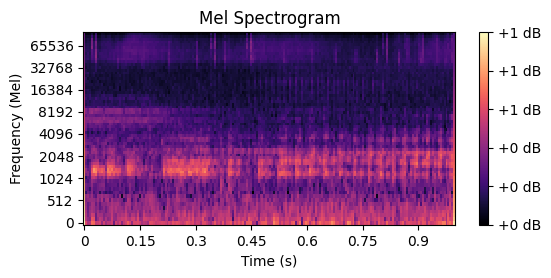


Model Predictions:
----------------
ECHO: TRUE (confidence: 100.00%)
HFPC: TRUE (confidence: 75.10%)
CC: TRUE (confidence: 63.70%)
Whistle: TRUE (confidence: 92.00%)
Call_Detection: TRUE (confidence: 100.00%)


In [5]:

start_s = 50
end_s = start_s + 1
clip = long_audio[sample_rate*start_s:sample_rate*end_s]

power_spect = spect_generator.compute_mel_power_spect(clip)
dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=hydrophone_sensitivity)
dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

spect_generator.plot_spect(dB_spect_normalized, figsize=(6, 2.5), transparent_background=True)
model_output = classify(dB_spect_resized, model, device)

predictions, probabilities = model_output[0]

print("\nModel Predictions:")
print("----------------")
for call_type in predictions:
    if predictions[call_type]:
        print(f"{call_type}: TRUE (confidence: {probabilities[call_type]:.2%})")
    else:
        print(f"{call_type}: FALSE (confidence: {probabilities[call_type]:.2%})")

### Running the pipeline on the whole file

In [6]:

results_df, summary_df = run_pipeline_batched_long_spects(
    long_audio,
    audio_start_time,
    sample_rate,
    model,
    device,
    spect_generator=spect_generator,
    debug=False,
    batch_size=128,
    call_model_window_s=1,
    hydrophone_sensitivity=hydrophone_sensitivity,
    # debug_at_s=120,
    # seconds_to_process=500,
    skip_first_n_seconds=4
)

[Thread 0] : 100%|█████████▉| 5389/5394 [00:24<00:00, 219.24it/s]

Spects generation time: 15.92 seconds
  Initial generation: 8.61 seconds
  dB conversion: 0.36 seconds
  Normalization: 0.26 seconds
  Resizing: 6.69 seconds
Inference time: 3.88 seconds
Noise calculation time: 4.53 seconds


### Summary of pipeline outputs on file :


In [7]:
summary_df

{'all_precise_noise_calc': True,
 'avg_noise_hf_range': 72.42763035813695,
 'avg_noise_w_range': 81.60154017442939,
 'avg_window_hf_range': 74.56015958433846,
 'avg_window_w_range': 82.74588977546854,
 'total_calls_detected': 4779,
 'echo_count': 3802,
 'hfpc_count': 280,
 'cc_count': 280,
 'whistle_count': 3300,
 'overall_call_rate': 53.17050088414439,
 'echo_rate': 42.292098763631564,
 'hfpc_rate': 3.114620634880809,
 'cc_rate': 3.114620634880809,
 'whistle_rate': 36.708028911095255}

### Pipeline raw outputs:

In [8]:
results_df.head(10)

,Timestamp,seconds_since_file_start,noise_calc_method,Call_Detection,ECHO,ECHO_prob,HFPC,HFPC_prob,CC,CC_prob,Whistle,Whistle_prob,db_window_w_range_mean,db_noise_w_range_mean,db_window_w_range_max,db_noise_w_range_max,db_window_w_range_min,db_noise_w_range_min,db_window_w_range_median,db_noise_w_range_median,snr_w_range_avg_window,snr_w_range_signal_active_time,snr_w_range_signal_present,snr_w_range_avg_signal,db_window_hf_range_mean,db_noise_hf_range_mean,db_window_hf_range_max,db_noise_hf_range_max,db_window_hf_range_min,db_noise_hf_range_min,db_window_hf_range_median,db_noise_hf_range_median,snr_hf_range_avg_window,snr_hf_range_signal_active_time,snr_hf_range_signal_present,snr_hf_range_avg_signal
0,2021-07-14 08:00:02,4.0,precise_with_model,1.0,True,1.0,False,0.022,False,0.0,True,1.0,81.0,77.8,135.2,119.2,56.4,55.3,77.9,76.5,7.18,0.63,1,9.85,83.0,72.7,100.3,84.3,72.5,66.9,82.7,72.7,11.10,0.98,1,11.20
1,2021-07-14 08:00:03,5.0,precise_with_model,1.0,True,1.0,False,0.419,False,0.0,True,1.0,81.7,77.8,116.7,119.2,63.3,55.3,78.4,76.5,10.93,0.70,1,14.41,85.2,72.7,102.6,84.3,74.1,66.9,84.2,72.7,12.59,0.99,1,12.63
2,2021-07-14 08:00:04,6.0,precise_with_model,1.0,True,1.0,False,0.000,False,0.0,True,1.0,82.2,77.8,117.4,119.2,59.0,55.3,79.2,76.5,11.93,0.86,1,13.32,80.4,72.7,100.3,84.3,70.3,66.9,79.3,72.7,7.35,0.61,1,10.00
3,2021-07-14 08:00:05,7.0,precise_with_model,1.0,True,1.0,False,0.000,False,0.0,True,1.0,81.9,77.8,124.9,119.2,64.4,55.3,78.8,76.5,10.71,0.79,1,12.58,78.3,72.7,96.8,84.3,68.8,66.9,76.9,72.7,5.20,0.41,1,10.07
4,2021-07-14 08:00:06,8.0,precise_with_model,1.0,True,1.0,False,0.000,False,0.0,False,0.0,80.8,77.8,117.0,119.2,58.8,55.3,77.7,76.5,5.80,0.64,1,7.09,77.2,72.7,91.4,84.3,69.7,66.9,75.8,72.7,4.24,0.32,1,10.31
5,2021-07-14 08:00:07,9.0,precise_with_model,1.0,True,1.0,True,0.975,False,0.0,True,1.0,82.0,77.8,128.1,119.2,60.4,55.3,78.8,76.5,8.94,0.81,1,10.23,76.0,72.7,90.9,84.3,68.8,66.9,74.8,72.7,3.05,0.26,1,9.32
6,2021-07-14 08:00:08,10.0,precise_with_model,1.0,True,1.0,False,0.000,False,0.0,False,0.0,81.3,77.8,117.9,119.2,63.2,55.3,78.0,76.5,7.70,0.87,1,8.35,79.9,72.7,111.4,84.3,69.4,66.9,78.0,72.7,8.11,0.44,1,13.98
7,2021-07-14 08:00:09,11.0,precise_with_model,1.0,True,1.0,False,0.000,False,0.0,False,0.0,81.3,77.8,117.7,119.2,59.6,55.3,77.4,76.5,8.78,0.90,1,9.30,80.1,72.7,111.3,84.3,71.3,66.9,79.2,72.7,7.90,0.73,1,9.21
8,2021-07-14 08:00:10,12.0,precise_with_model,1.0,True,1.0,False,0.000,False,0.0,False,0.0,81.2,77.8,116.9,119.2,63.4,55.3,76.7,76.5,9.86,0.96,1,10.13,79.1,72.7,113.5,84.3,70.5,66.9,77.7,72.7,6.75,0.36,1,12.69
9,2021-07-14 08:00:11,13.0,precise_with_model,1.0,True,1.0,False,0.000,False,0.0,True,1.0,82.1,77.8,118.1,119.2,62.8,55.3,77.6,76.5,11.71,0.98,1,11.87,76.3,72.7,111.0,84.3,68.8,66.9,75.3,72.7,3.83,0.16,1,15.29


# Visualization of Outputs

The main function for visualizing model outputs is `plot_pipeline_outputs_on_spects`, which provides fine-grained control over when and how to display the results. You can adjust the following parameters:

- **`start_from_sec`**: Change the starting second for displaying outputs
- **`chunk_duration`**: Set the duration of each spectrogram chunk
- **`num_chunks`**: Control the number of spectrograms to display

Results are displayed in chunks, allowing you to focus on specific time segments of your audio file.

## Performance Analysis

The `analyze_pipeline_performance` method also uses `plot_pipeline_outputs_on_spects` but provides a more comprehensive view across the entire file. Using the `uniform` method, it uniformly samples `n_samples` points throughout the file and displays `num_chunks` of `chunk_duration` length.

This approach has proven highly useful for obtaining a robust overview of pipeline performance across different audio conditions and identifying locations with unusual audio artifacts or noise.


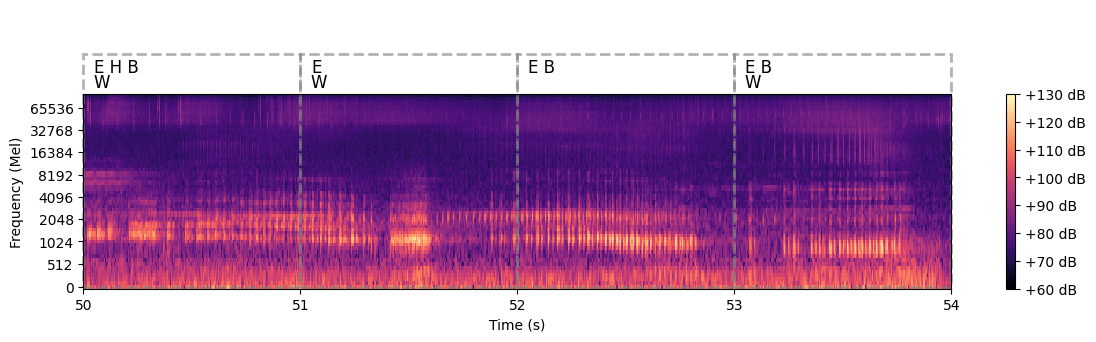

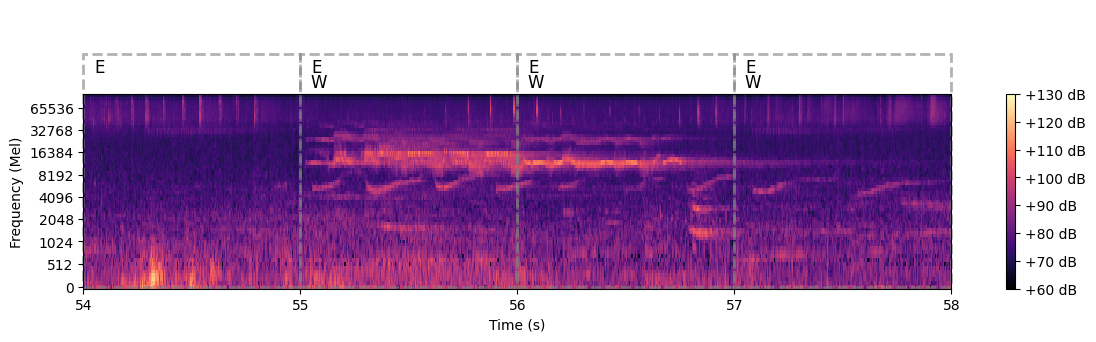

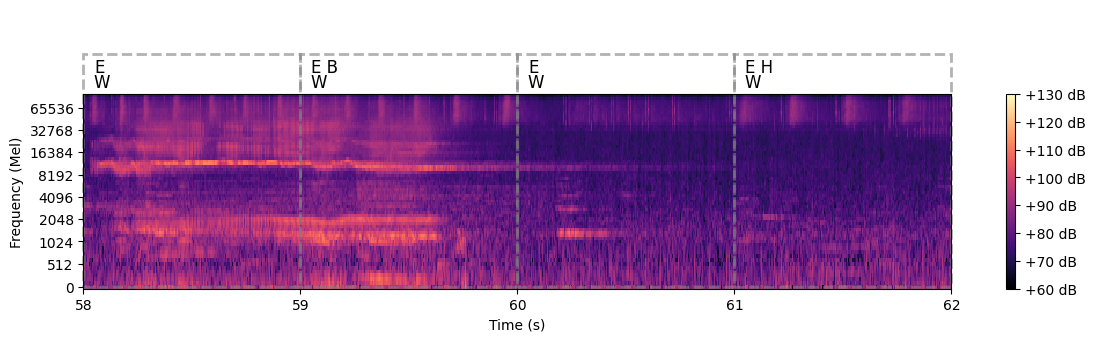

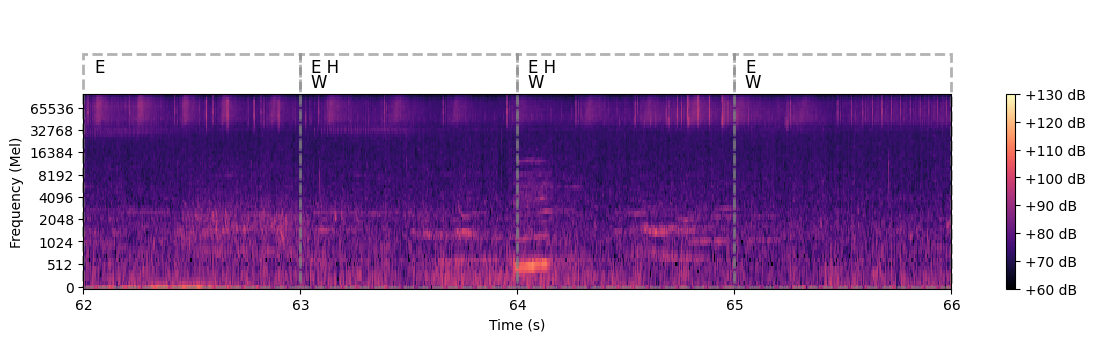

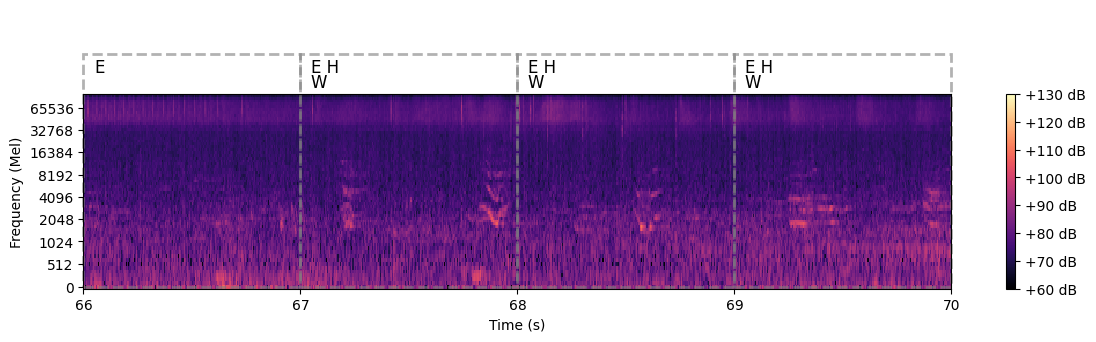

In [10]:
plot_pipeline_outputs_on_spects(
    start_from_sec=50.0,
    num_chunks=5,
    chunk_duration=4,
    show_probabilities=False,
    audio=long_audio,
    sr=sample_rate,
    results_df=results_df,
    audio_start_time=audio_start_time,
    labels=None,
    hydrophone_sensitivity=hydrophone_sensitivity,
    show_call_predictions=True,
    show_snr_stats=False,
    figsize=(14, 3.3),
    
    vmin=60,
    vmax=130,
    start_time_ticks_0=False,
    show_title=False,
)


📊 Showing uniformly sampled audio segments:
Checking at 0.0% through audio file (0.0s / 5393.9s)


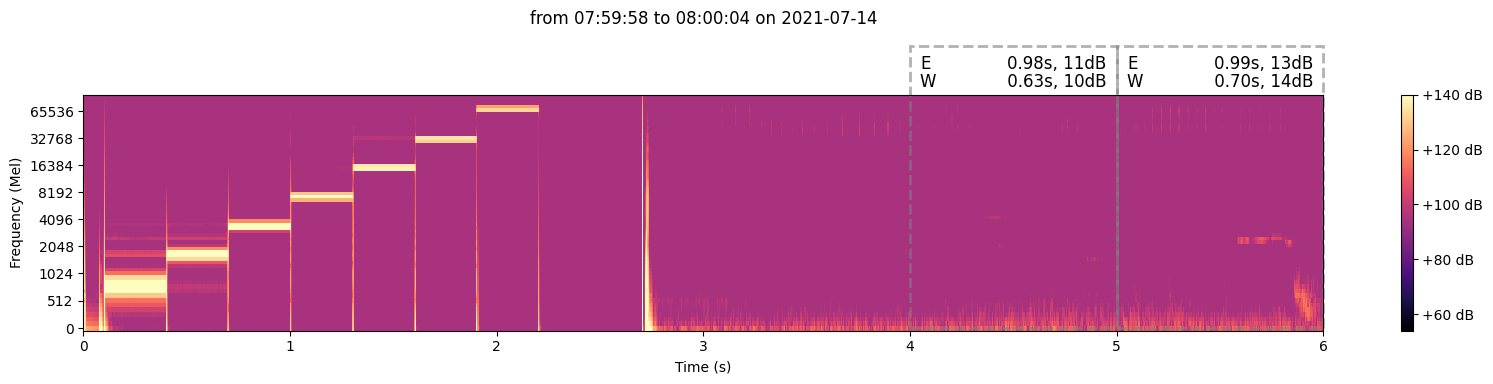

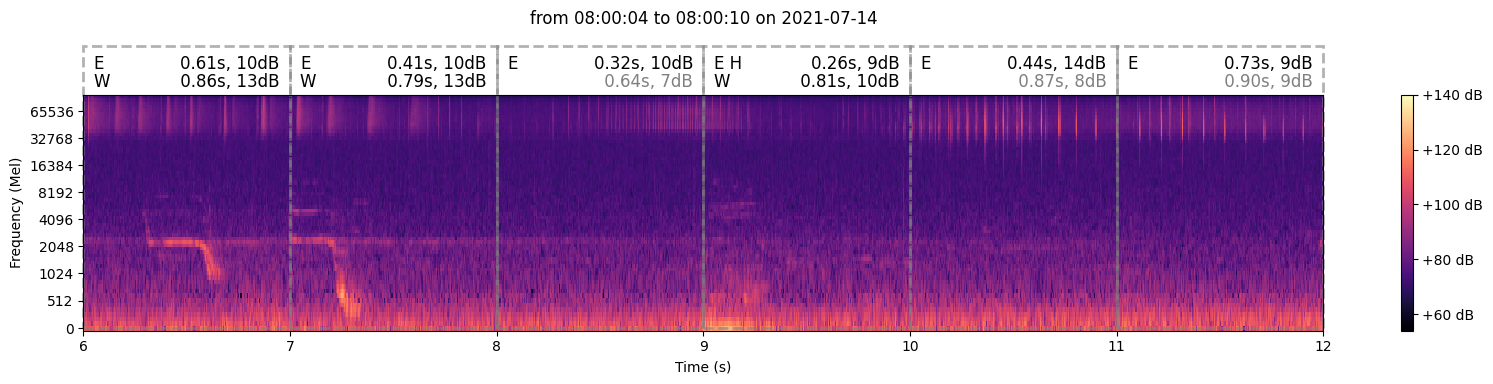



Checking at 11.1% through audio file (598.0s / 5393.9s)


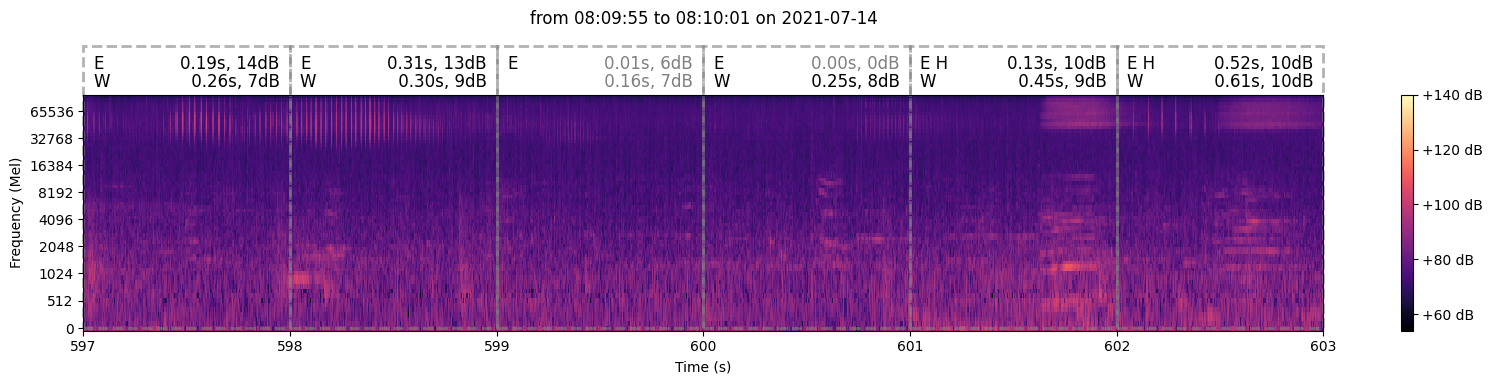

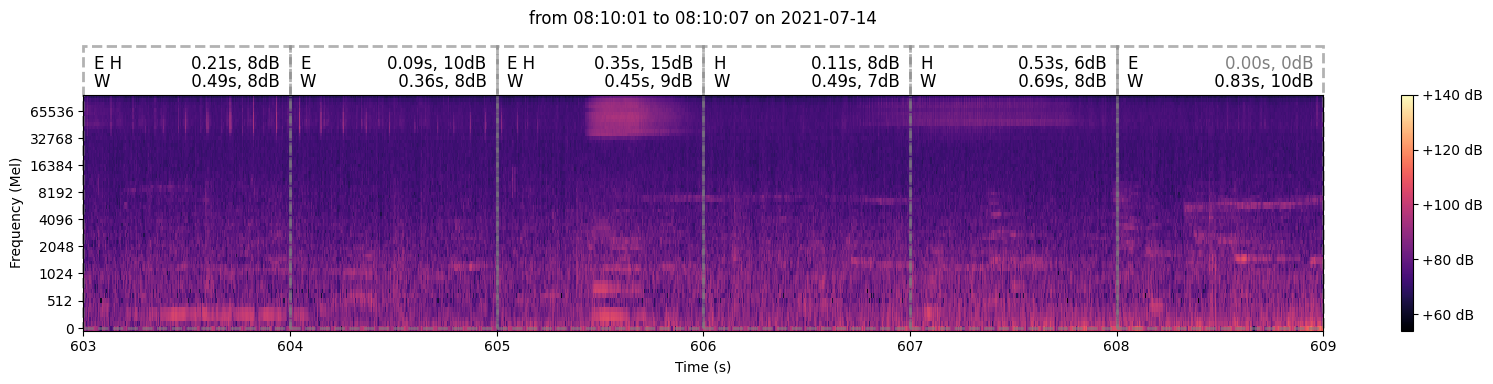



Checking at 22.2% through audio file (1196.0s / 5393.9s)


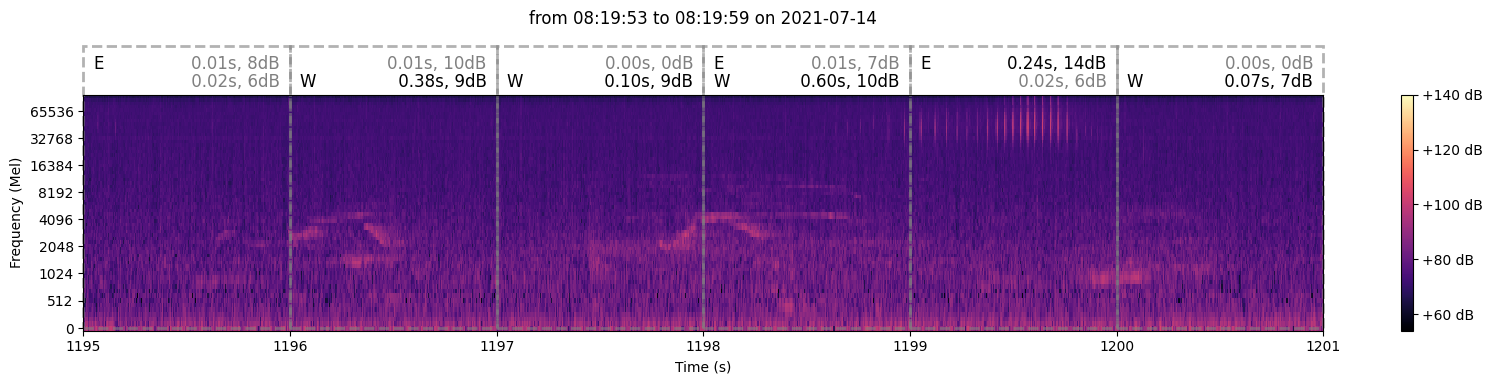

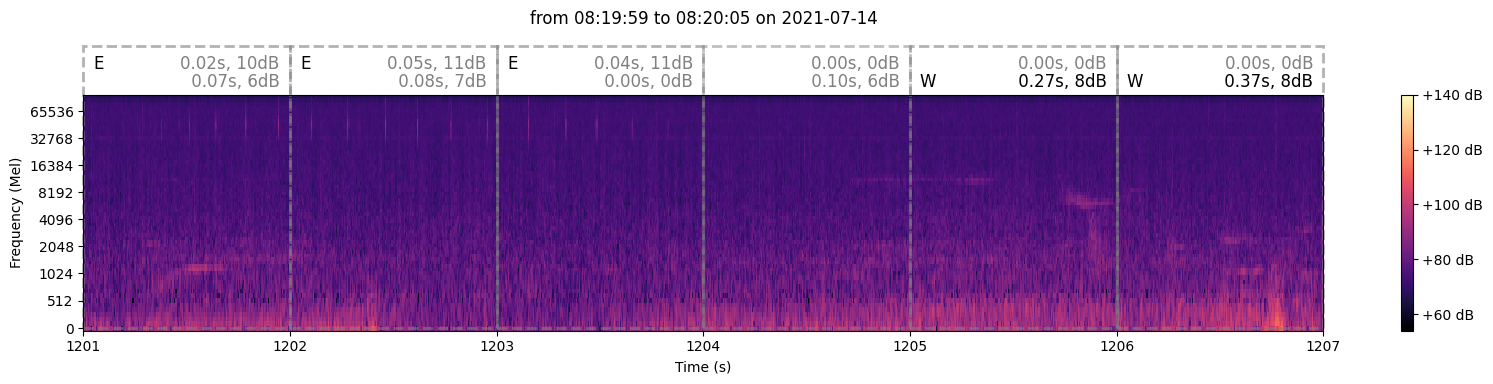



Checking at 33.3% through audio file (1794.0s / 5393.9s)


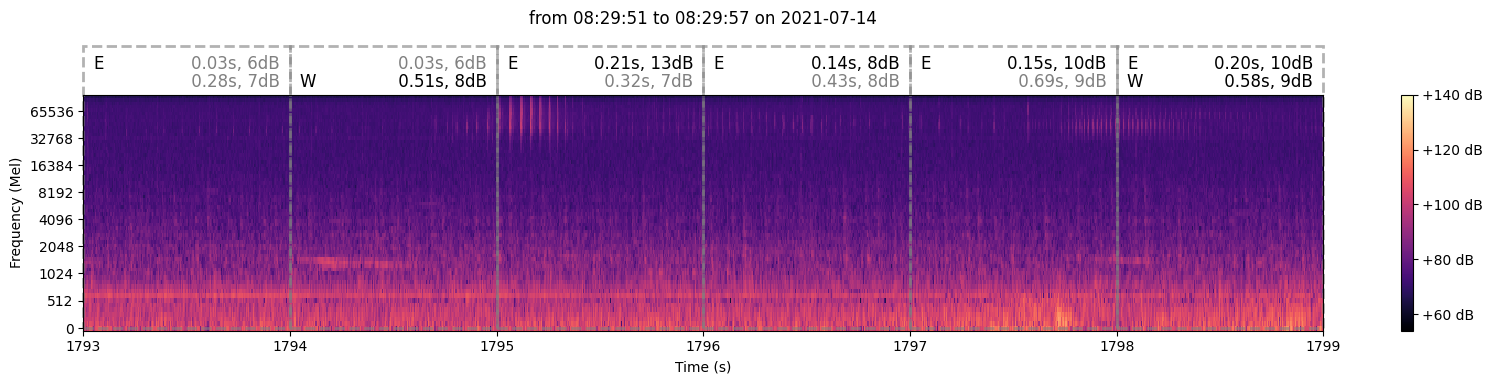

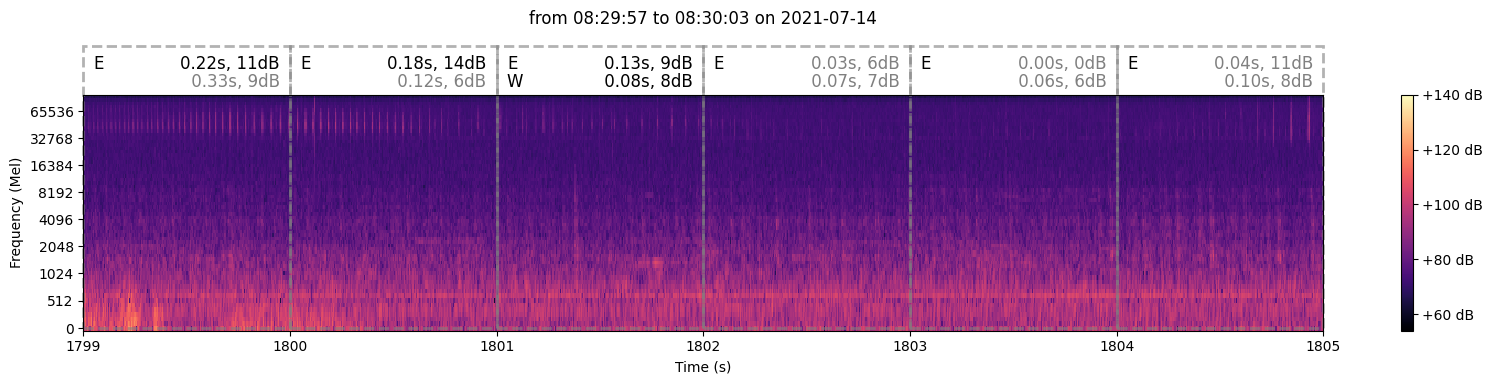



Checking at 44.3% through audio file (2392.0s / 5393.9s)


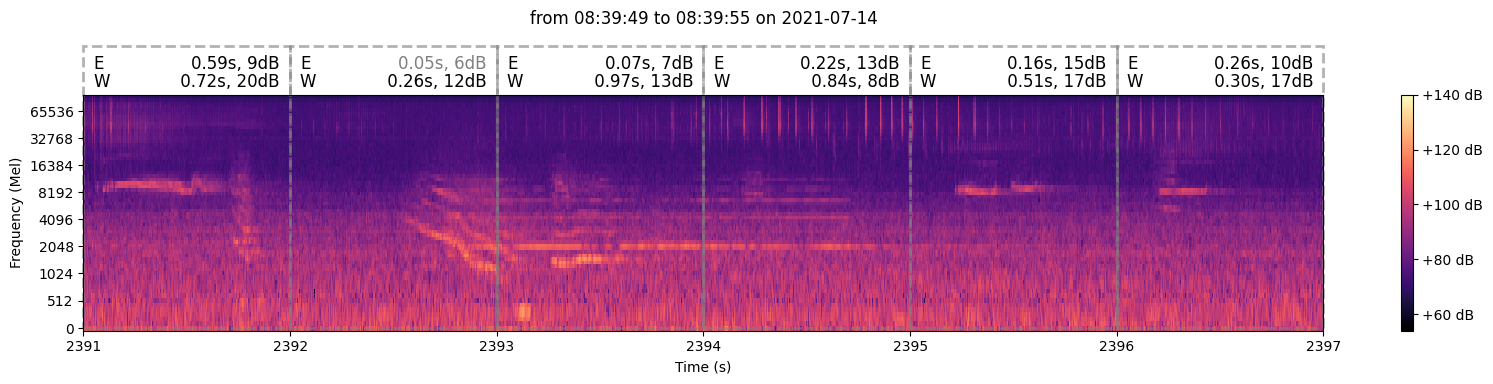

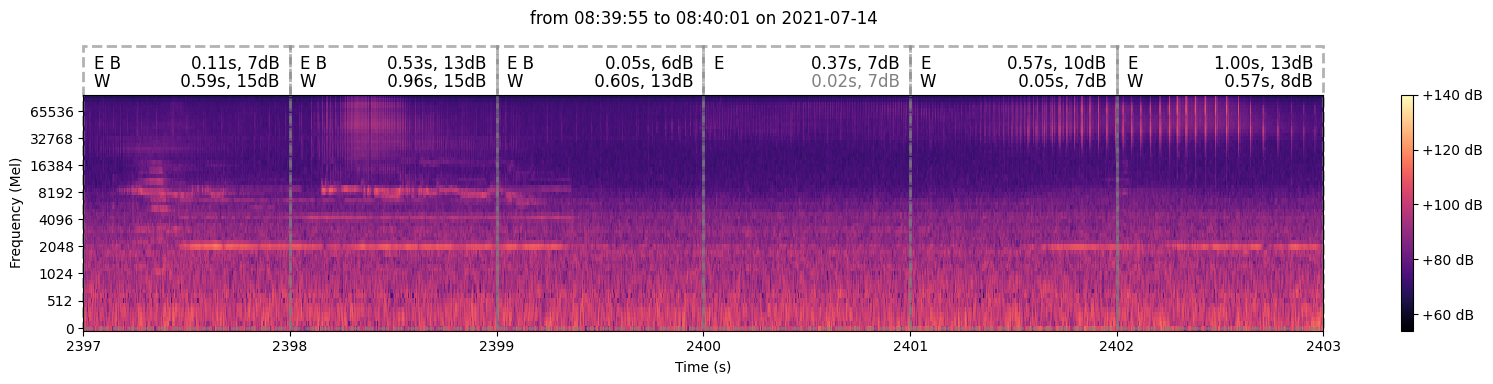



Checking at 55.4% through audio file (2990.0s / 5393.9s)


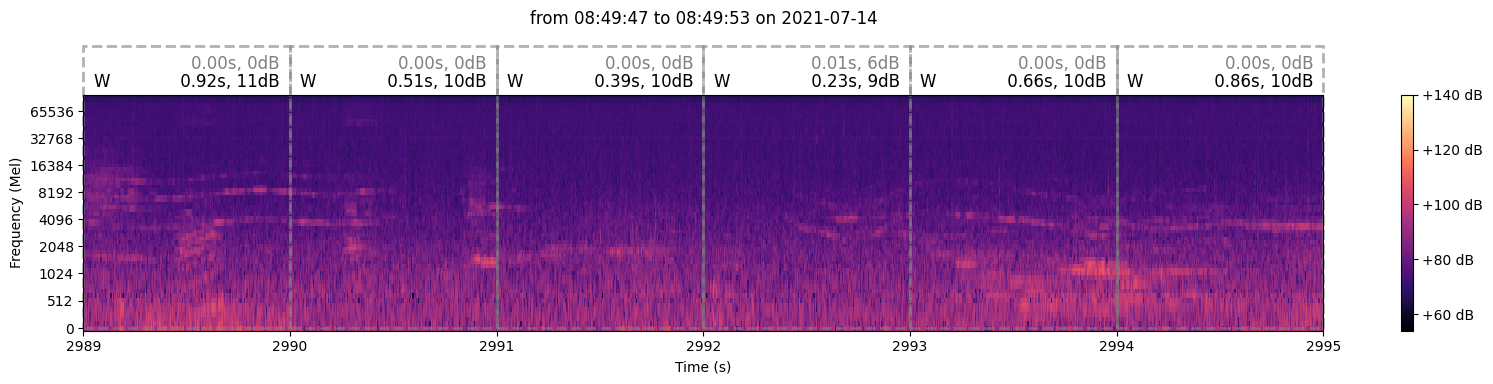

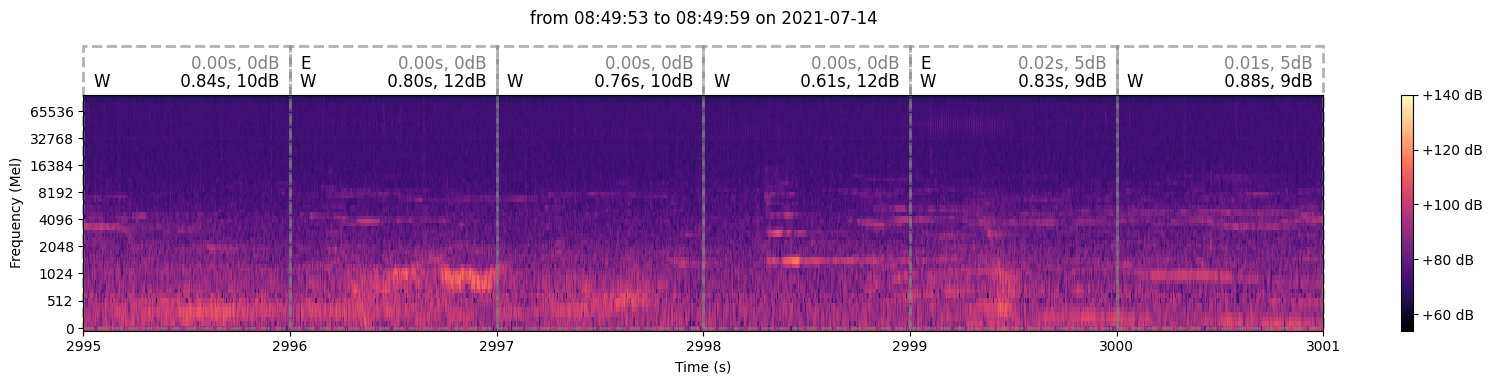



Checking at 66.5% through audio file (3587.9s / 5393.9s)


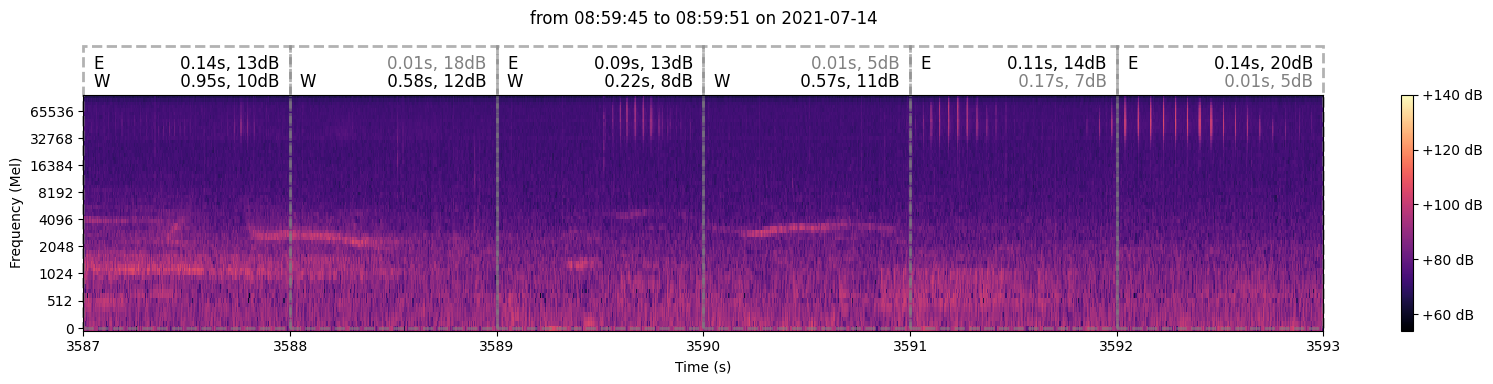

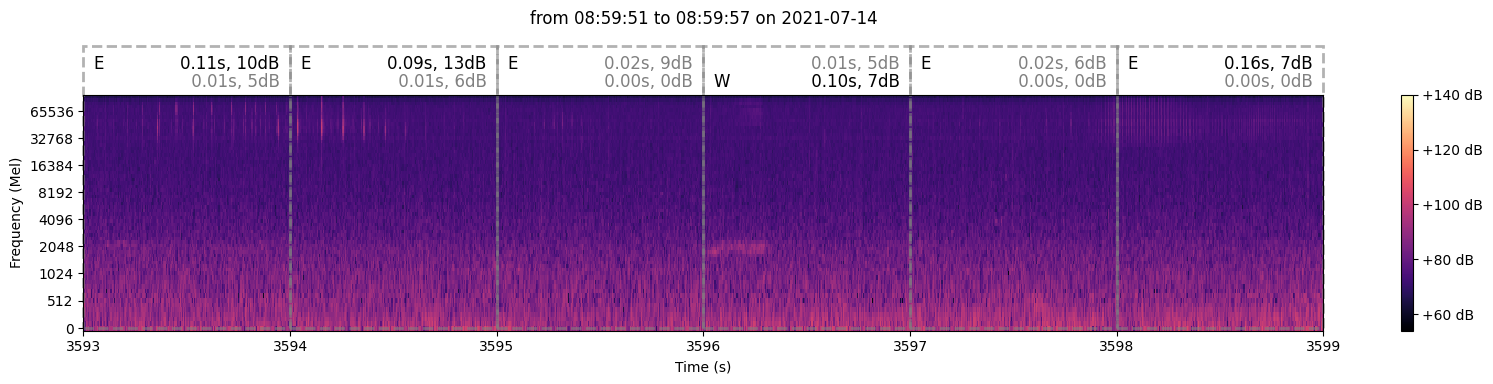



Checking at 77.6% through audio file (4185.9s / 5393.9s)


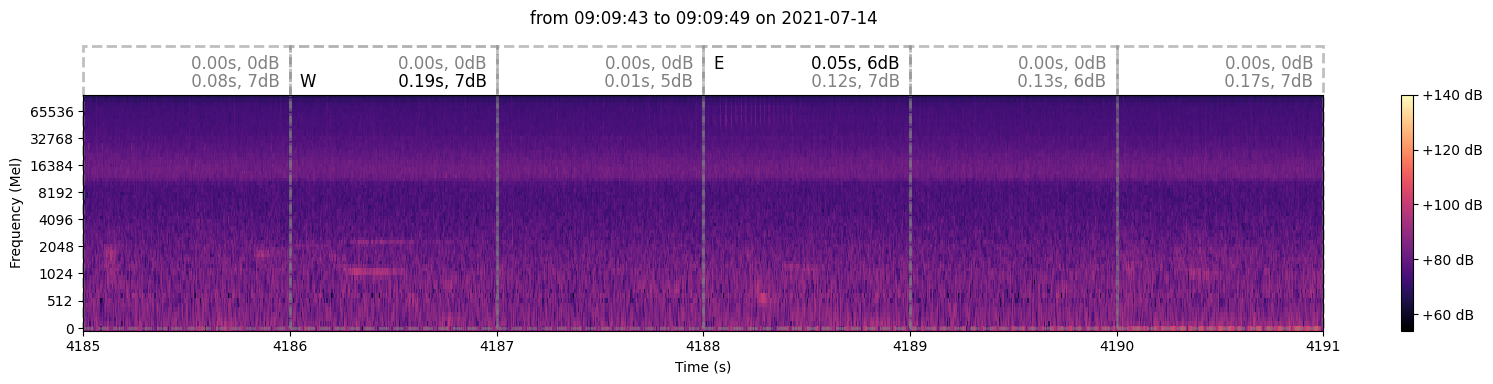

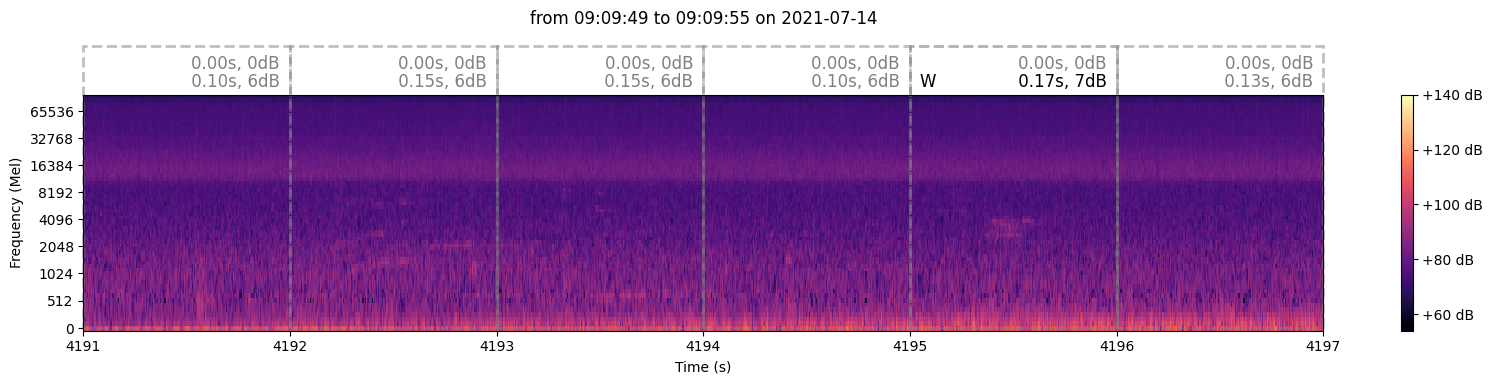



Checking at 88.7% through audio file (4783.9s / 5393.9s)


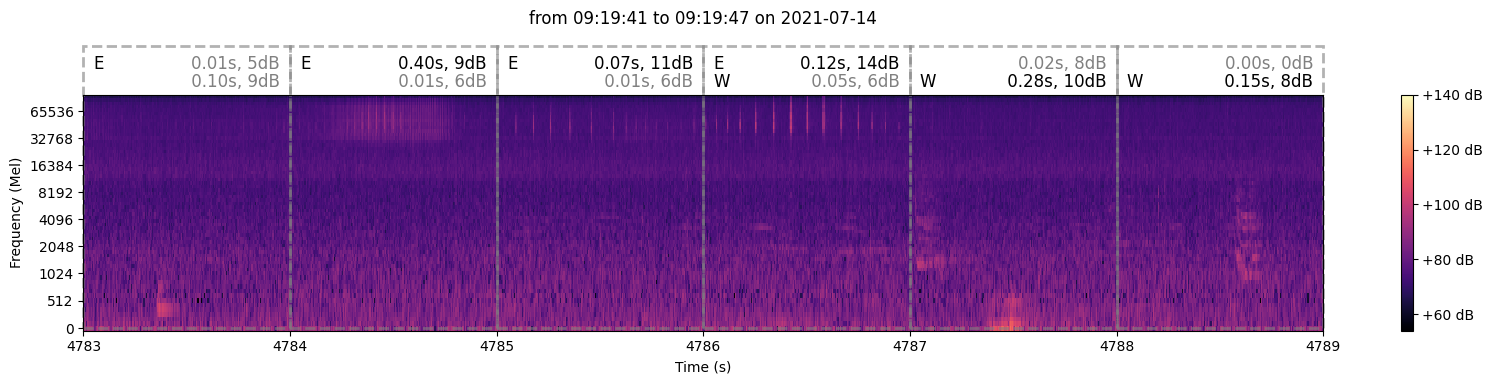

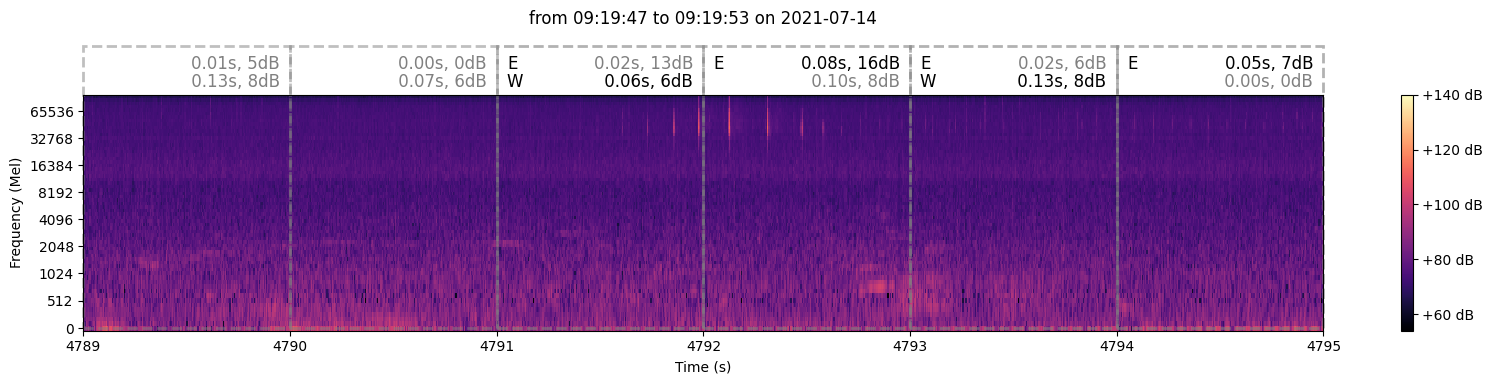



Checking at 99.8% through audio file (5381.9s / 5393.9s)


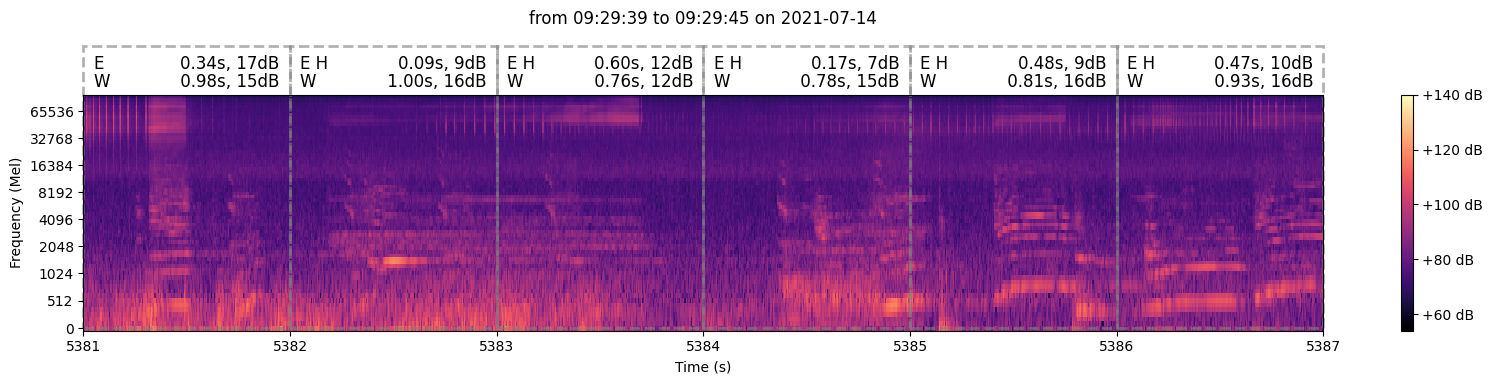

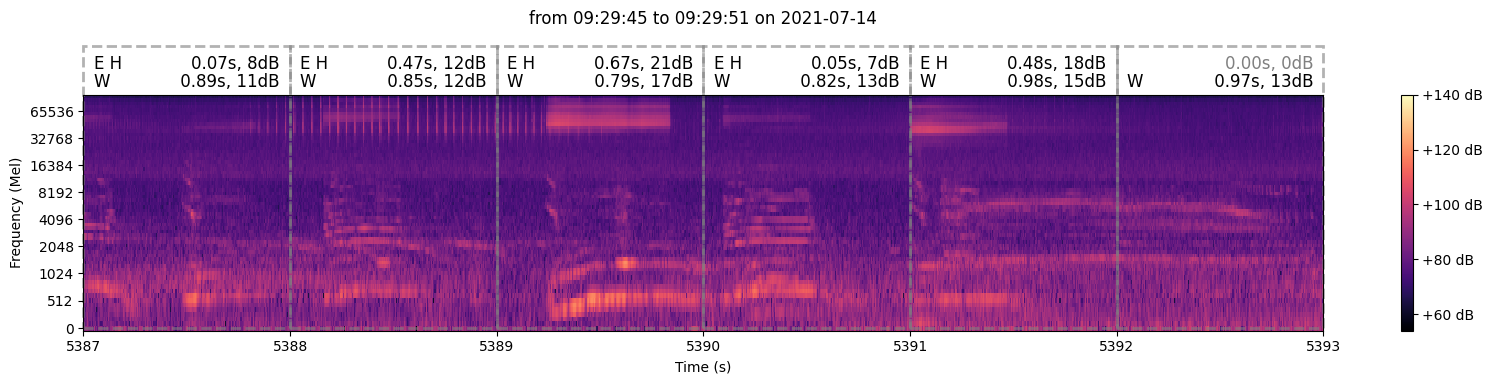

In [46]:
analyze_pipeline_performance(
    long_audio,
    sample_rate,
    results_df,
    audio_start_time,
    hydrophone_sensitivity,
    n_samples=10,
    chunk_duration=6,
    num_chunks=2,
    vmin=140,
    vmax=60,
    method="uniform"
)